In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from cartopy.feature import ShapelyFeature
import cartopy.crs as ccrs
import matplotlib.patches as mpatches

In [5]:
# in this section, write the script to load the data and complete the main part of the analysis.
# try to print the results to the screen using the format method demonstrated in the workbook

# load the necessary data here and transform to a UTM projection
counties = gpd.read_file("data_files/Counties.shp")
wards = gpd.read_file("data_files/NI_Wards.shp")

# convert both to Irish Transverse Mercator first (EPSG:2157)
counties = counties.to_crs(epsg=2157)
wards = wards.to_crs(epsg=2157)

# then convert to UTM zone 29 (to match the map projection)
counties = counties.to_crs(epsg=32629)
wards = wards.to_crs(epsg=32629)

In [7]:
print(wards.columns)

Index(['Ward Code', 'Ward', 'Population', 'geometry'], dtype='str')


In [8]:
joined = gpd.sjoin(wards, counties, how="left", predicate="intersects")
summary = joined.groupby("CountyName")["Population"].sum().reset_index()
highest = summary.sort_values("Population", ascending=False).iloc[0]
lowest = summary.sort_values("Population", ascending=True).iloc[0]

print("Highest population county: {} ({})".format(highest["CountyName"], highest["Population"]))
print("Lowest population county: {} ({})".format(lowest["CountyName"], lowest["Population"]))
counties = counties.merge(summary, on="CountyName")

Highest population county: ANTRIM (718369)
Lowest population county: FERMANAGH (75906)


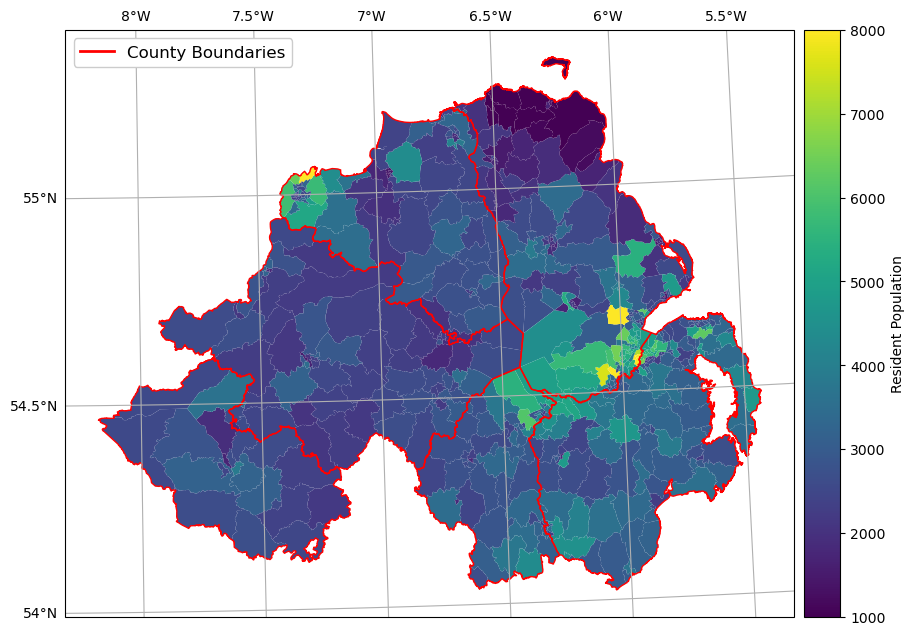

In [4]:
# your analysis goes here...

# ---------------------------------------------------------------------------------------------------------------------
# below here, you may need to modify the script somewhat to create your map.
# create a crs using ccrs.UTM() that corresponds to our CRS
ni_utm = ccrs.UTM(29)

# create a figure of size 10x10 (representing the page size in inches
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw=dict(projection=ni_utm))

# add gridlines below
gridlines = ax.gridlines(draw_labels=True,
                         xlocs=[-8, -7.5, -7, -6.5, -6, -5.5],
                         ylocs=[54, 54.5, 55, 55.5])
gridlines.right_labels = False
gridlines.bottom_labels = False

# to make a nice colorbar that stays in line with our map, use these lines:
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1, axes_class=plt.Axes)

# plot the ward data into our axis, using gdf.plot()
ward_plot = wards.plot(column='Population', ax=ax, vmin=1000, vmax=8000, cmap='viridis',
                       legend=True, cax=cax, legend_kwds={'label': 'Resident Population'})

# add county outlines in red using ShapelyFeature
county_outlines = ShapelyFeature(counties['geometry'], ni_utm, edgecolor='r', facecolor='none')
ax.add_feature(county_outlines)

from matplotlib.lines import Line2D

county_handles = [Line2D([0], [0], color='r', lw=2)]

# add a legend in the upper left-hand corner
ax.legend(county_handles, ['County Boundaries'], fontsize=12, loc='upper left', framealpha=1)

# save the figure
fig.savefig('sample_map.png', dpi=300, bbox_inches='tight')

In [9]:
ward_counts = joined.groupby("Ward Code").size().reset_index(name="count")
multi_wards = ward_counts[ward_counts["count"] > 1]
print("Number of wards in multiple counties:", len(multi_wards))
multi_pop = joined[joined["Ward Code"].isin(multi_wards["Ward Code"])]

total_population = multi_pop["Population"].sum()

print("Total population of these wards:", total_population)
highest = wards.sort_values("Population", ascending=False).iloc[0]
lowest = wards.sort_values("Population", ascending=True).iloc[0]

print("Highest population ward: {} ({})".format(highest["Ward Code"], highest["Population"]))
print("Lowest population ward: {} ({})".format(lowest["Ward Code"], lowest["Population"]))
wards["Area_km2"] = wards.geometry.area / 1_000_000
wards["Density"] = wards["Population"] / wards["Area_km2"]
highest_density = wards.sort_values("Density", ascending=False).iloc[0]
print("Highest density ward: {} ({})".format(highest_density["Ward Code"], highest_density["Density"]))
lowest_density = wards.sort_values("Density", ascending=True).iloc[0]
print("Lowest density ward: {} ({})".format(lowest_density["Ward Code"], lowest_density["Density"]))

Number of wards in multiple counties: 115
Total population of these wards: 788155
Highest population ward: 95SS07 (9464)
Lowest population ward: 95UU04 (738)
Highest density ward: 95GG02 (10274.542412508814)
Lowest density ward: 95UU11 (8.231053365631434)
